<a href="https://colab.research.google.com/github/hyrinn/Machine_Learning/blob/main/Basecode_Perceptron_MINIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 패키지 선언

In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader

## Dataset 다운로드

In [2]:
# Training dataset 다운로드
mnist_train = dataset.MNIST(root = "./",
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
mnist_test = dataset.MNIST(root = "./",
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.09MB/s]


## MNIST 데이터셋 형상 확인

60000
torch.Size([1, 28, 28])
5


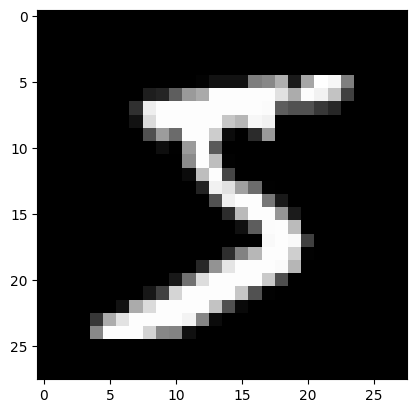

In [3]:
import matplotlib.pyplot as plt
print(len(mnist_train))     # training dataset 개수 확인

first_data = mnist_train[0]
print(first_data[0].shape)  # 첫번째 data의 형상 확인
print(first_data[1])        # 첫번째 data의 정답 확인

plt.imshow(first_data[0][0,:,:], cmap='gray')
plt.show()

In [4]:
first_img = first_data[0]
print(first_img.shape)

first_img = first_img.view(-1, 28*28) # 이미지 평탄화 수행 2D -> 1D
print(first_img.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


## Single Layer Perceptron 모델 정의


In [5]:
class SLP(nn.Module):

  def __init__(self):
    super(SLP, self).__init__()
    self.fc = nn.Linear(in_features = 784, out_features = 10)

  def forward(self, x):
    x = x.view(-1, 28*28)
    y = self.fc(x)
    return y


## Multi Layer Perceptron 모델 정의 (2-layer)

In [6]:
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.fc1 = nn.Linear(in_features = 784, out_features = 300)
    self.fc2 = nn.Linear(in_features = 300, out_features = 100)
    self.fc3 = nn.Linear(in_features = 100, out_features = 50)
    self.fc4 = nn.Linear(in_features = 50, out_features = 10)
    self.active = nn.Sigmoid()


  def forward(self, x):
    x = x.view(-1, 28*28)
    y = self.active(self.fc1(x))
    y = self.active(self.fc2(y))
    y = self.active(self.fc3(y))
    y = self.fc4(y)

    # y = self.fc1(x)
    # y = self.fc2(y)
    # y = self.active(self.fc3(y))
    # y = self.fc4(y)
    return y


## Hyper-parameters 지정

In [7]:
batch_size = 100
learning_rate = 0.1
training_epochs = 10
loss_function = nn.CrossEntropyLoss()
network = MLP()
#optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)
optimizer = torch.optim.Adam(network.parameters(), lr = learning_rate)
data_loader = DataLoader(dataset=mnist_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [8]:
network.train()

for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward() # 역전파
    optimizer.step()

    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

/tmp/ipykernel_563/4020024521.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))


Epoch: 1 Loss = 2.388073
Epoch: 2 Loss = 2.376817
Epoch: 3 Loss = 2.364630
Epoch: 4 Loss = 2.368065
Epoch: 5 Loss = 2.366523
Epoch: 6 Loss = 2.372374
Epoch: 7 Loss = 2.363142
Epoch: 8 Loss = 2.371597
Epoch: 9 Loss = 2.374427
Epoch: 10 Loss = 2.373725
Learning finished


## 학습이 완료된 모델을 이용해 정답률 확인

In [9]:
network.eval()

img_test = mnist_test.data.float()
label_test = mnist_test.targets

with torch.no_grad(): # test에서는 기울기 계산 제외
  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.10279999673366547


## 예측 결과 확인

tensor([[0.8093, 0.9430, 0.5809, 0.7210, 0.7614, 0.5101, 0.6886, 1.0070, 0.0331,
         0.9796]])
tensor([7])


<function matplotlib.pyplot.show(close=None, block=None)>

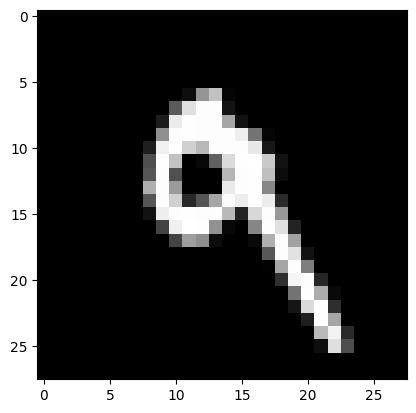

In [10]:
first_data = mnist_test.data[7]

with torch.no_grad():
  prediction = network(first_data.float())

prediction_num = torch.argmax(prediction, 1)

print(prediction)
print(prediction_num)
plt.imshow(first_data, cmap="gray")
plt.show